## SETUP

In [28]:
import sys
import subprocess

# Install required packages for this notebook
required_packages = ["torch", "torchvision", "torchaudio", "soundfile", "matplotlib"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")

import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class SpeechDigitDataset(Dataset):
    def __init__(self, data_dir, is_train=True, audio_aug=False, img_aug=False):
        self.data_dir = data_dir
        self.filepaths = []
        self.labels = []
        self.audio_aug = audio_aug
        self.img_aug = img_aug

        subset_dir = 'Train' if is_train else 'Test'
        full_subset_path = os.path.join(data_dir, subset_dir)
        if not os.path.exists(full_subset_path):
            print(f"Warning: Directory not found: {full_subset_path}")
        else:
            for file in os.listdir(full_subset_path):
                if file.endswith('.wav'):
                    filepath = os.path.join(full_subset_path, file)
                    self.filepaths.append(filepath)
                    try:
                        label = int(file.split('_')[1].split('.')[0])
                        self.labels.append(label)
                    except (IndexError, ValueError):
                        pass

        self.spectrogramer = T.MelSpectrogram(sample_rate=16000, n_mels=64)
        self.resize = transforms.Resize((32, 32))
        # Reduced SpecAugment parameters to avoid over-augmentation
        self.freq_mask = T.FrequencyMasking(freq_mask_param=7)
        self.time_mask = T.TimeMasking(time_mask_param=7)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]
        waveform, sample_rate = torchaudio.load(path)

        if self.audio_aug:
            noise = torch.randn_like(waveform) * 0.002
            waveform = waveform + noise

        spec = self.spectrogramer(waveform)
        spec = torchaudio.transforms.AmplitudeToDB()(spec)
        spec = self.resize(spec)

        if self.img_aug:
            # Apply Spectrum Augmentation (SpecAugment) - reduced intensity
            spec = self.freq_mask(spec)
            spec = self.time_mask(spec)

        return spec, label

Using device: cuda


In [29]:
print('Installing ffmpeg...')
!apt-get -qq install ffmpeg
print('ffmpeg installed.')

Installing ffmpeg...
ffmpeg installed.


## **1: Setup and Environment**

In [30]:
import sys
import subprocess

# Install required packages for this notebook
required_packages = ["torch", "torchvision", "torchaudio", "matplotlib"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")


In [31]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Google Colab Drive mounting (commented out for local use)
# from google.colab import drive
# drive.mount('/content/drive')

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [32]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import math

# Google Colab Drive mounting (commented out for local use)
from google.colab import drive
drive.mount('/content/drive')

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [33]:
import sys
import subprocess

print("Python executable:", sys.executable)
print("Python version:", sys.version)

# Ensure required packages are installed in the current kernel environment
required_packages = ["torch", "torchvision", "torchaudio"]
for pkg in required_packages:
    try:
        __import__(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print(f"Installed {pkg}")


Python executable: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## **Question 3 - Speech Recognition & Augmentation**

**Objective**: Convert speech .wav files into spectrograms and train a CNN.


In [ ]:
YOUR_AUDIO_PATH = "/content/drive/MyDrive/SHARED/Assignments/NNs/audio-dataset"
class SpectrogramCNN(nn.Module):
    def __init__(self, dropout=0.3, use_bn=True):
        super(SpectrogramCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=5)
        self.bn1 = nn.BatchNorm2d(8) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 24, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(24) if use_bn else nn.Identity()
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(24 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        return self.fc3(x)

In [41]:
class SpectrogramCNN(nn.Module):
    def __init__(self, dropout=0.4, use_bn=True):
        super(SpectrogramCNN, self).__init__()
        # First Layer: Captures low-level frequency features
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) if use_bn else nn.Identity()
        self.pool = nn.MaxPool2d(2, 2)

        # Second Layer: Deeper feature extraction
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32) if use_bn else nn.Identity()

        # Third Layer: Increasing capacity for complex patterns
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64) if use_bn else nn.Identity()

        self.dropout = nn.Dropout(dropout)

        # Based on 32x32 input, 3 pools (2x2) = 4x4 feature map
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        return self.fc3(x)

Audio data path: /content/drive/MyDrive/SHARED/Assignments/NNs/audio-dataset
Number of fetched training audio samples: 1200
Number of fetched testing audio samples: 300


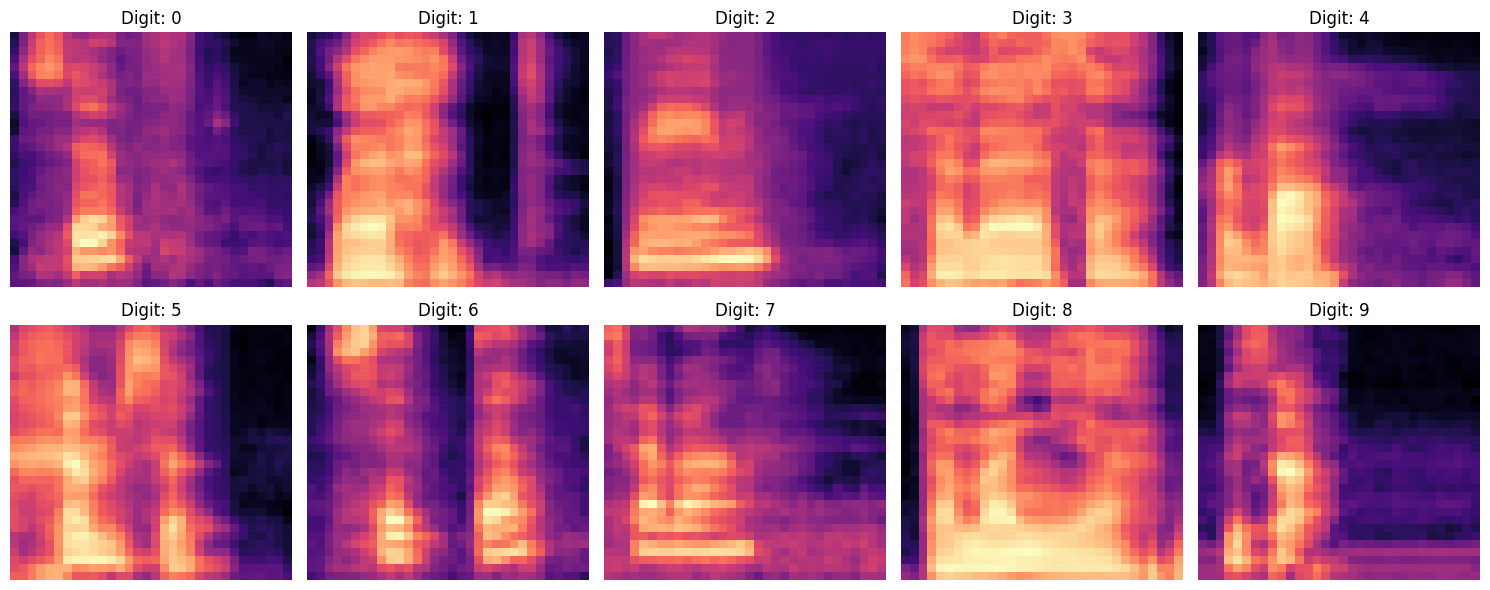

In [42]:
print(f"Audio data path: {YOUR_AUDIO_PATH}")

# Check if directory exists before proceeding
if not os.path.exists(YOUR_AUDIO_PATH):
    print(f"Error: The path {YOUR_AUDIO_PATH} does not exist. Please check your Google Drive folder structure.")
else:
    # Initialize datasets to count samples
    try:
        train_ds_info = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=True, audio_aug=False, img_aug=False)
        test_ds_info = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=False, audio_aug=False, img_aug=False)

        print(f"Number of fetched training audio samples: {len(train_ds_info)}")
        print(f"Number of fetched testing audio samples: {len(test_ds_info)}")

        if len(train_ds_info) == 0 or len(test_ds_info) == 0:
            print("Warning: One or both datasets are empty. Please check subdirectory names ('Train', 'Test') inside your Drive folder.")
    except Exception as e:
        print(f"An error occurred while loading dataset info: {e}")

# Visualization code remains available if data is found
if 'train_ds_info' in locals() and len(train_ds_info) > 0:
    vis_ds = train_ds_info
    samples_per_digit = {}
    for spec, label in vis_ds:
        if label not in samples_per_digit:
            samples_per_digit[label] = spec.squeeze().numpy()
        if len(samples_per_digit) == 10: break

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i, (label, spec_np) in enumerate(sorted(samples_per_digit.items())):
        axes[i].imshow(spec_np, origin='lower', aspect='auto', cmap='magma')
        axes[i].set_title(f'Digit: {label}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

## **Running the 4 scenarios for Question 3**
**Objective**: Run experiments A, B, C, and D based on combinations of audio and image augmentations.

In [43]:
def run_speech_experiment(audio_aug, img_aug, exp_name, epochs=20):
    print(f"\n--- Running Experiment: {exp_name} ---")
    train_ds = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=True, audio_aug=audio_aug, img_aug=img_aug)
    test_ds = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=False, audio_aug=False, img_aug=False)

    if len(train_ds) == 0:
        print("Warning: No audio files found. Check YOUR_AUDIO_PATH.")
        return None

    train_ldr = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_ldr = DataLoader(test_ds, batch_size=32, shuffle=False)

    model = SpectrogramCNN(dropout=0.3, use_bn=True).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = []
    best_acc = 0.0
    best_model_state = None
    save_dir = os.path.join(os.path.dirname(YOUR_AUDIO_PATH), "saved_models")
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        train_start = time.time()
        for images, labels in train_ldr:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_time = (time.time() - train_start) * 1000
        avg_train_loss = running_loss / len(train_ldr)

        # --- Testing ---
        model.eval()
        correct, total = 0, 0
        epoch_test_loss = 0.0
        test_start = time.time()
        with torch.no_grad():
            for images, labels in test_ldr:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_time = (time.time() - test_start) * 1000

        avg_test_loss = epoch_test_loss / len(test_ldr)
        epoch_accuracy = 100 * correct / total
        history.append(epoch_accuracy)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, "
              f"Test Accuracy: {epoch_accuracy:.2f}%, LR: {current_lr:.6f}, "
              f"Train Time: {train_time:.1f}ms, Test Time: {test_time:.1f}ms")

        # Save best model
        if epoch_accuracy > best_acc:
            best_acc = epoch_accuracy
            best_model_state = model.state_dict().copy()

        scheduler.step()

    # Save the best model to disk
    safe_name = exp_name.replace(" ", "_").replace(":", "")
    save_path = os.path.join(save_dir, f"best_{safe_name}.pth")
    if best_model_state is not None:
        torch.save(best_model_state, save_path)
        print(f"Best model saved to {save_path} (Accuracy: {best_acc:.2f}%)")

    print(f"Final Best Accuracy: {best_acc:.2f}%")
    return {'history': history, 'best_acc': best_acc}

In [ ]:
def plot_speech_results(results_dict):
    # 1. Comparison Bar Chart
    names = list(results_dict.keys())
    accuracies = [results_dict[n]['best_acc'] for n in names]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(names, accuracies, color=['skyblue', 'lightgreen', 'salmon', 'plum'])
    plt.ylabel('Best Test Accuracy (%)')
    plt.title('Comparison of Augmentation Scenarios')
    plt.ylim(0, 100)

    # Add labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center')

    plt.tight_layout()
    plt.show()

    # 2. Learning Curves
    plt.figure(figsize=(14, 7))
    for name in names:
        plt.plot(results_dict[name]['history'], label=name, marker='o')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Improvement Over Epochs')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


--- Starting All Experiments ---

--- Running Experiment: Scenario A: No Augmentation ---
  Epoch 1/30, Train Loss: 2.0721, Test Loss: 1.4947, Test Accuracy: 62.00%, LR: 0.001000, Train Time: 6915.5ms, Test Time: 1713.2ms
  Epoch 2/30, Train Loss: 1.1337, Test Loss: 0.5325, Test Accuracy: 88.00%, LR: 0.000997, Train Time: 7806.0ms, Test Time: 1681.0ms
  Epoch 3/30, Train Loss: 0.5721, Test Loss: 0.2409, Test Accuracy: 92.67%, LR: 0.000989, Train Time: 7859.9ms, Test Time: 1728.0ms
  Epoch 4/30, Train Loss: 0.3092, Test Loss: 0.1955, Test Accuracy: 92.67%, LR: 0.000976, Train Time: 6913.1ms, Test Time: 1807.1ms
  Epoch 5/30, Train Loss: 0.1719, Test Loss: 0.1778, Test Accuracy: 95.00%, LR: 0.000957, Train Time: 7684.2ms, Test Time: 1662.2ms
  Epoch 6/30, Train Loss: 0.1419, Test Loss: 0.0481, Test Accuracy: 98.33%, LR: 0.000934, Train Time: 7840.7ms, Test Time: 1682.9ms
  Epoch 7/30, Train Loss: 0.1099, Test Loss: 0.0803, Test Accuracy: 97.33%, LR: 0.000905, Train Time: 6873.0ms, Test T

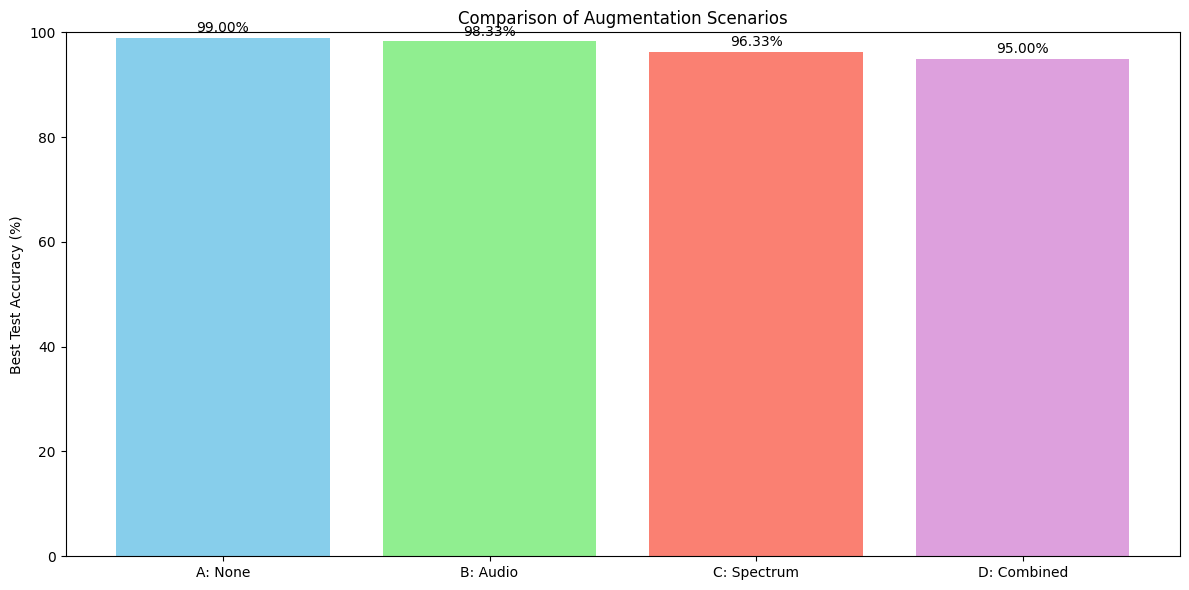

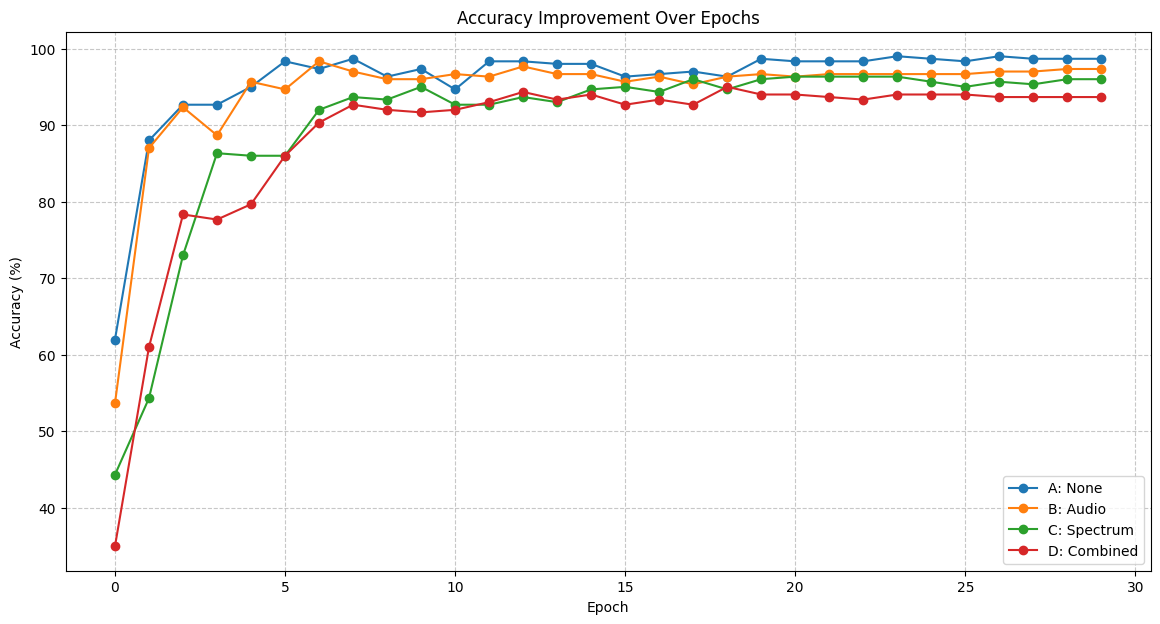

In [45]:
print("--- Starting All Experiments ---")
speech_results = {}

speech_results["A: None"] = run_speech_experiment(audio_aug=False, img_aug=False, exp_name="Scenario A: No Augmentation", epochs=30)
speech_results["B: Audio"] = run_speech_experiment(audio_aug=True, img_aug=False, exp_name="Scenario B: Audio Augmentation Only", epochs=30)
speech_results["C: Spectrum"] = run_speech_experiment(audio_aug=False, img_aug=True, exp_name="Scenario C: Spectrum Augmentation Only", epochs=30)
speech_results["D: Combined"] = run_speech_experiment(audio_aug=True, img_aug=True, exp_name="Scenario D: Combined Augmentation", epochs=30)

print("\n--- All Experiments Completed. Generating Graphs... ---")
final_speech_data = {k: v for k, v in speech_results.items() if v is not None}
if final_speech_data:
    plot_speech_results(final_speech_data)
else:
    print("No results to plot.")